# 02_EDA探索分析

## 目标
- 完成订单、支付、履约时效的探索分析，识别关键分布和异常。

## 输入
- olist_orders_dataset.csv、olist_order_items_dataset.csv、olist_order_payments_dataset.csv、olist_order_reviews_dataset.csv

## 输出
- 核心探索图表与异常点总结。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/df_master.csv", parse_dates=['order_purchase_timestamp',
    'order_delivered_customer_date','order_estimated_delivery_date'])

print("数据加载完成，shape：", df.shape)
df.head(3)

数据加载完成，shape： (113264, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,total_payment,payment_installments,product_category_name,product_category_name_english,review_score,purchase_year,purchase_month,purchase_hour,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,38.71,1.0,utilidades_domesticas,housewares,4.0,2017,10,10,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,141.46,1.0,perfumaria,perfumery,4.0,2018,7,20,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,179.12,3.0,automotivo,auto,5.0,2018,8,8,9.0


## 步骤1：订单状态分布


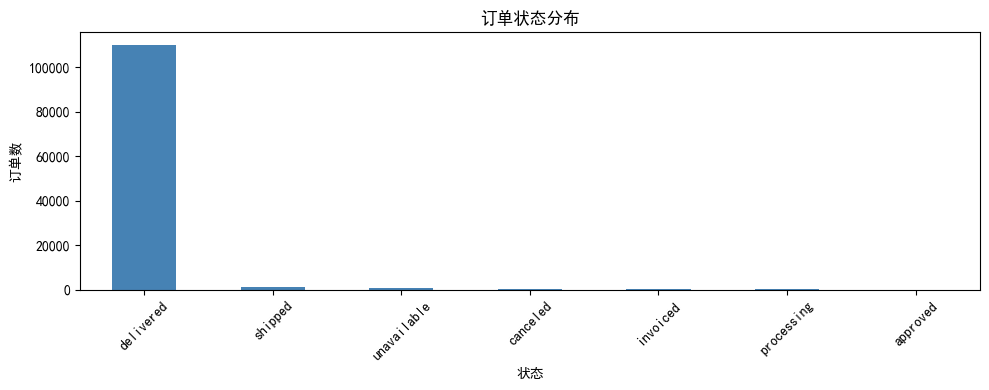

order_status
delivered      110182
shipped          1186
unavailable       610
canceled          565
invoiced          361
processing        357
approved            3
Name: count, dtype: int64


In [6]:
status_counts = df['order_status'].value_counts()
plt.figure(figsize=(10, 4))
status_counts.plot(kind='bar', color='steelblue')
plt.title('订单状态分布')
plt.xlabel('状态')
plt.ylabel('订单数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(status_counts)

## 步骤2：月度订单趋势


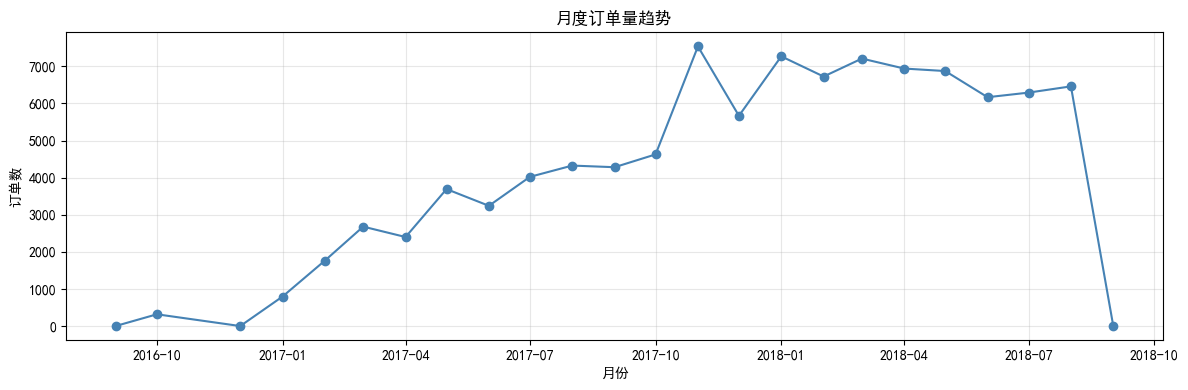

订单高峰月份：          date  order_id
13 2017-11-01      7535
15 2018-01-01      7268
17 2018-03-01      7208


In [8]:
monthly = df.groupby(['purchase_year','purchase_month'])['order_id'].nunique().reset_index()
monthly['date'] = pd.to_datetime({
    'year': monthly['purchase_year'],
    'month': monthly['purchase_month'],
    'day': 1
})
monthly = monthly.sort_values('date')

plt.figure(figsize=(12, 4))
plt.plot(monthly['date'], monthly['order_id'], marker='o', color='steelblue')
plt.title('月度订单量趋势')
plt.xlabel('月份')
plt.ylabel('订单数')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("订单高峰月份：", monthly.nlargest(3,'order_id')[['date','order_id']])

## 步骤3：用户购买时段分布


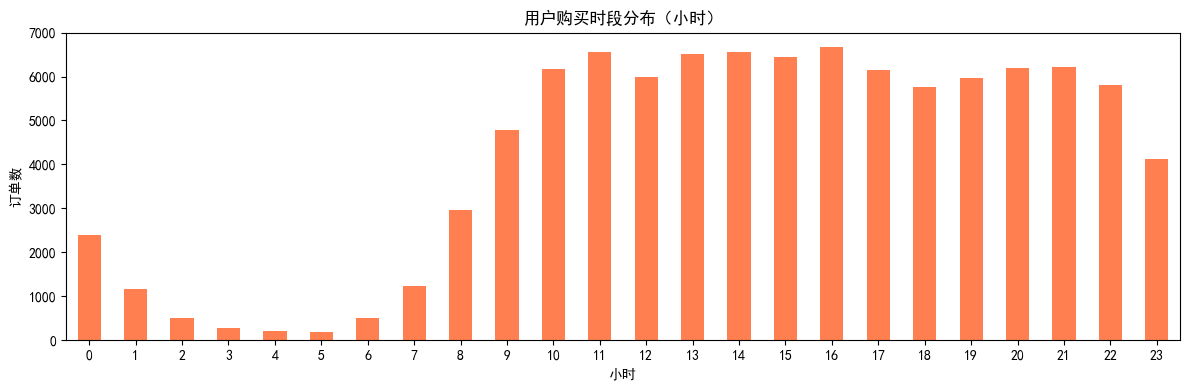

购买高峰时段 Top3： purchase_hour
16    6667
11    6567
14    6557
Name: order_id, dtype: int64


In [9]:
hour_counts = df.groupby('purchase_hour')['order_id'].nunique()

plt.figure(figsize=(12, 4))
hour_counts.plot(kind='bar', color='coral')
plt.title('用户购买时段分布（小时）')
plt.xlabel('小时')
plt.ylabel('订单数')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("购买高峰时段 Top3：", hour_counts.nlargest(3))

## 步骤4：品类销售分布


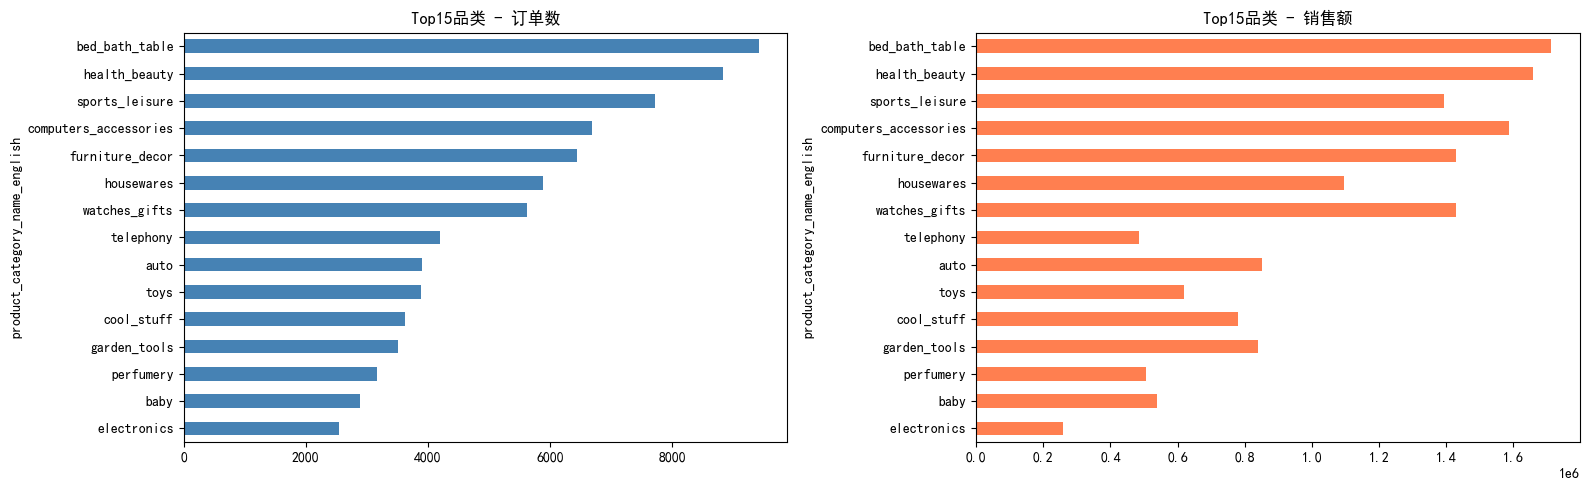

                                订单数        总销售额
product_category_name_english                  
bed_bath_table                 9416  1712396.48
health_beauty                  8836  1657373.12
sports_leisure                 7718  1392033.10
computers_accessories          6689  1585330.45
furniture_decor                6446  1429875.48
housewares                     5884  1094758.13
watches_gifts                  5624  1429216.68
telephony                      4198   486627.97
auto                           3897   852294.33
toys                           3886   619037.69
cool_stuff                     3629   779388.62
garden_tools                   3517   838126.52
perfumery                      3162   506738.66
baby                           2885   539845.66
electronics                    2550   259857.10


In [10]:
category_sales = df.groupby('product_category_name_english').agg(
    订单数=('order_id','nunique'),
    总销售额=('total_payment','sum')
).sort_values('订单数', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

category_sales['订单数'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top15品类 - 订单数')
axes[0].invert_yaxis()

category_sales['总销售额'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top15品类 - 销售额')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(category_sales)

## 步骤5：配送时长分析


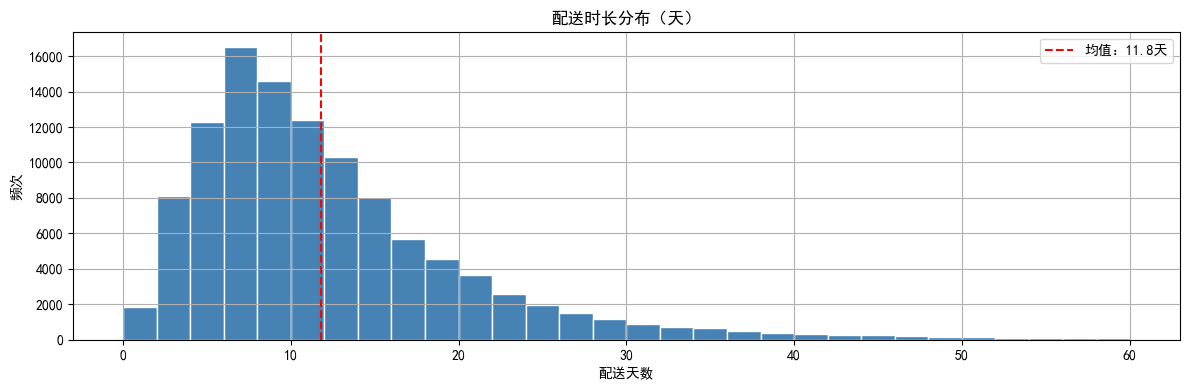

配送时长统计：
count    109863.000000
mean         11.791859
std           8.345581
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max          60.000000
Name: delivery_days, dtype: float64


In [11]:
delivered = df[df['order_status']=='delivered'].copy()
delivered = delivered.dropna(subset=['delivery_days'])
delivered = delivered[delivered['delivery_days'].between(0, 60)]

plt.figure(figsize=(12, 4))
delivered['delivery_days'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('配送时长分布（天）')
plt.xlabel('配送天数')
plt.ylabel('频次')
plt.axvline(delivered['delivery_days'].mean(), color='red', 
            linestyle='--', label=f"均值：{delivered['delivery_days'].mean():.1f}天")
plt.legend()
plt.tight_layout()
plt.show()

print("配送时长统计：")
print(delivered['delivery_days'].describe())

## 步骤6：评分分布


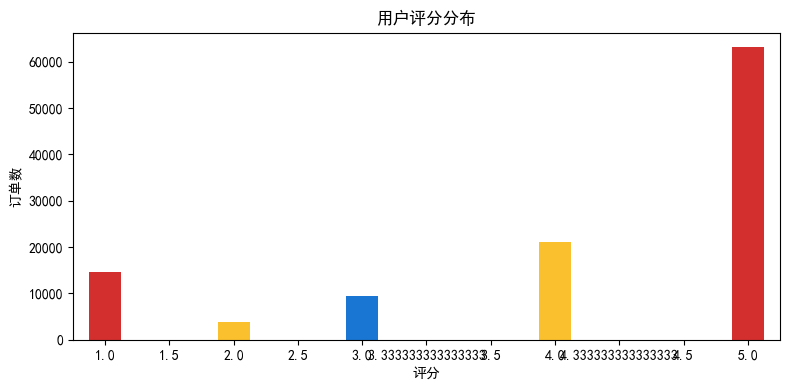

平均评分： 4.02
好评率（4-5分）： 75.1%


In [14]:
score_counts = df['review_score'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
score_counts.plot(kind='bar', color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2'])
plt.title('用户评分分布')
plt.xlabel('评分')
plt.ylabel('订单数')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("平均评分：", df['review_score'].mean().round(2))
print("好评率（4-5分）：", 
      f"{(df['review_score']>=4).sum()/df['review_score'].notna().sum()*100:.1f}%")

## 步骤7：EDA核心结论


## EDA核心发现

1. **订单趋势**：2017年下半年起快速增长，2018年达到高峰
2. **购买时段**：用户集中在上午10点-下午4点下单，夜间活跃度低
3. **热门品类**：bed_bath_table / health_beauty / sports_leisure 是Top3品类
4. **配送时长**：平均配送约12天，存在长尾配送超时问题
5. **用户评分**：平均分约4.0，好评率约77%，低分集中在1星